第一题

<div style="font-size: 12px;">

### 1. 非线性激活函数的重要性

**证明：**

已知网络的前向传播过程为：
- 隐藏层： $\mathbf{h} = \mathbf{W}_1\mathbf{x} + \mathbf{b}_1$
- 输出层： $\mathbf{o} = \mathbf{W}_2\mathbf{h} + \mathbf{b}_2$

将隐藏层 $\mathbf{h}$ 的表达式代入输出层 $\mathbf{o}$ 的表达式中，得到：
$$ \mathbf{o} = \mathbf{W}_2(\mathbf{W}_1\mathbf{x} + \mathbf{b}_1) + \mathbf{b}_2 $$
$$ \mathbf{o} = \mathbf{W}_2\mathbf{W}_1\mathbf{x} + \mathbf{W}_2\mathbf{b}_1 + \mathbf{b}_2 $$

令 $\mathbf{W}' = \mathbf{W}_2\mathbf{W}_1$，$\mathbf{b}' = \mathbf{W}_2\mathbf{b}_1 + \mathbf{b}_2$，则输出层的表达式可以简化为：
$$ \mathbf{o} = \mathbf{W}'\mathbf{x} + \mathbf{b}' $$

该表达式与不包含隐藏层的单层神经网络的等式形式完全一致。因此，如果没有非线性激活函数，无论增加多少隐藏层，多层感知机网络最终都等价于一个单层线性网络，无法学习复杂的非线性映射。

等价后的权重矩阵与偏置向量分别为：
- **权重矩阵：** $\mathbf{W}' = \mathbf{W}_2\mathbf{W}_1$
- **偏置向量：** $\mathbf{b}' = \mathbf{W}_2\mathbf{b}_1 + \mathbf{b}_2$

---

### 2. 激活函数性质分析

#### (1) Sigmoid 函数
**数学表达式：**
$$ \text{Sigmoid}(x) = \sigma(x) = \frac{1}{1 + e^{-x}} $$

**导数推导与自身关系：**
$$ \sigma'(x) = \frac{d}{dx} (1 + e^{-x})^{-1} $$
$$ \sigma'(x) = -1 \cdot (1 + e^{-x})^{-2} \cdot (-e^{-x}) $$
$$ \sigma'(x) = \frac{e^{-x}}{(1 + e^{-x})^2} $$
$$ \sigma'(x) = \frac{1}{1 + e^{-x}} \cdot \frac{e^{-x}}{1 + e^{-x}} $$
因为 $1 - \sigma(x) = 1 - \frac{1}{1 + e^{-x}} = \frac{e^{-x}}{1 + e^{-x}}$，所以上式可化简为：
$$ \sigma'(x) = \sigma(x)(1 - \sigma(x)) $$

#### (2) tanh 函数
**数学表达式：**
$$ \tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}} $$

**导数推导与自身关系：**
$$ \tanh'(x) = \frac{d}{dx} \left( \frac{e^x - e^{-x}}{e^x + e^{-x}} \right) $$
根据商的求导法则 $\left(\frac{u}{v}\right)' = \frac{u'v - uv'}{v^2}$：
$$ \tanh'(x) = \frac{(e^x + e^{-x})(e^x + e^{-x}) - (e^x - e^{-x})(e^x - e^{-x})}{(e^x + e^{-x})^2} $$
$$ \tanh'(x) = \frac{(e^x + e^{-x})^2}{(e^x + e^{-x})^2} - \frac{(e^x - e^{-x})^2}{(e^x + e^{-x})^2} $$
$$ \tanh'(x) = 1 - \left( \frac{e^x - e^{-x}}{e^x + e^{-x}} \right)^2 $$
$$ \tanh'(x) = 1 - \tanh^2(x) $$

</div>

下载数据集

In [3]:
import torch
import torchvision
import torchvision.transforms as transforms

# 将图像数据转换为 PyTorch Tensor，并将像素值从 0~255 缩放到 0~1 的范围
trans = transforms.ToTensor()

# 下载并加载训练集
mnist_train = torchvision.datasets.FashionMNIST(
    root="./data",       # 数据集下载后保存的目录，会在当前文件夹下创建一个 data 文件夹
    train=True,          # 指定获取训练集
    transform=trans,     # 应用上面的转换
    download=True        # 如果本地没有数据，则自动从网上下载
)

# 下载并加载测试集
mnist_test = torchvision.datasets.FashionMNIST(
    root="./data",
    train=False,         # 指定获取测试集
    transform=trans,
    download=True
)

print(f"训练集大小: {len(mnist_train)}")
print(f"测试集大小: {len(mnist_test)}")

Using downloaded and verified file: ./data\FashionMNIST\raw\train-images-idx3-ubyte.gz
Extracting ./data\FashionMNIST\raw\train-images-idx3-ubyte.gz to ./data\FashionMNIST\raw

Using downloaded and verified file: ./data\FashionMNIST\raw\train-labels-idx1-ubyte.gz
Extracting ./data\FashionMNIST\raw\train-labels-idx1-ubyte.gz to ./data\FashionMNIST\raw

Using downloaded and verified file: ./data\FashionMNIST\raw\t10k-images-idx3-ubyte.gz
Extracting ./data\FashionMNIST\raw\t10k-images-idx3-ubyte.gz to ./data\FashionMNIST\raw

Using downloaded and verified file: ./data\FashionMNIST\raw\t10k-labels-idx1-ubyte.gz
Extracting ./data\FashionMNIST\raw\t10k-labels-idx1-ubyte.gz to ./data\FashionMNIST\raw

训练集大小: 60000
测试集大小: 10000


不使用深度学习框架的高级 API（仅使用 Tensor 基础算子如 torch.matmul
等），纯 NumPy 或 PyTorch 从零实现一个多分类（使用 Fashion-MNIST
数据集）的单隐藏层 MLP。

In [4]:
import torch
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader

# ==========================================
# 准备 Fashion-MNIST 数据集
# ==========================================
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.FashionMNIST(root='./data', train=False, transform=transform, download=True)

batch_size = 256
train_iter = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_iter = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# ==========================================
# 1. 手动初始化参数 (单隐藏层，256个隐藏单元)
# ==========================================
num_inputs = 28 * 28 
num_hiddens = 256    
num_outputs = 10     

W1 = torch.normal(0, 0.01, size=(num_inputs, num_hiddens), requires_grad=True)
b1 = torch.zeros(num_hiddens, requires_grad=True)
W2 = torch.normal(0, 0.01, size=(num_hiddens, num_outputs), requires_grad=True)
b2 = torch.zeros(num_outputs, requires_grad=True)

params = [W1, b1, W2, b2]

# ==========================================
# 2. 实现 ReLU 激活函数的前向传播
# ==========================================
def relu(X):
    a = torch.zeros_like(X)
    return torch.max(X, a)

def net(X):
    X = X.reshape((-1, num_inputs))
    H = relu(torch.matmul(X, W1) + b1)
    return torch.matmul(H, W2) + b2

# ==========================================
# 3. 带有 Softmax 的交叉熵损失函数
# ==========================================
def cross_entropy(y_hat, y):
    y_hat_max, _ = torch.max(y_hat, dim=1, keepdim=True)
    y_hat_shifted = y_hat - y_hat_max
    exp_y_hat = torch.exp(y_hat_shifted)
    partition = exp_y_hat.sum(dim=1, keepdim=True)
    log_prob = y_hat_shifted - torch.log(partition)
    return -log_prob[range(len(y_hat)), y]

# ==========================================
# 4. 编写训练循环，通过小批量随机梯度下降 (SGD) 手动更新参数
# ==========================================
def sgd(params, lr, batch_size):
    with torch.no_grad():
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_()

def accuracy(y_hat, y):
    if len(y_hat.shape) > 1 and y_hat.shape[1] > 1:
        y_hat = y_hat.argmax(axis=1)
    cmp = y_hat.type(y.dtype) == y
    return float(cmp.type(y.dtype).sum())

num_epochs = 10
lr = 0.1

print("开始训练...")
for epoch in range(num_epochs):
    train_loss_sum = 0.0
    train_acc_sum = 0.0
    n = 0
    
    for X, y in train_iter:
        y_hat = net(X)
        l = cross_entropy(y_hat, y).sum()
        
        l.backward()
        sgd(params, lr, batch_size)
        
        with torch.no_grad():
            train_loss_sum += l.item()
            train_acc_sum += accuracy(y_hat, y)
            n += y.numel()
            
    test_acc_sum = 0.0
    test_n = 0
    with torch.no_grad():
        for X, y in test_iter:
            test_acc_sum += accuracy(net(X), y)
            test_n += y.numel()
            
    train_loss = train_loss_sum / n
    train_acc = train_acc_sum / n
    test_acc = test_acc_sum / test_n
    
    print(f'Epoch {epoch + 1:2d}: Loss = {train_loss:.4f}, Train Acc = {train_acc:.4f}, Test Acc = {test_acc:.4f}')

print("训练结束！")

开始训练...
Epoch  1: Loss = 1.0406, Train Acc = 0.6370, Test Acc = 0.7569
Epoch  2: Loss = 0.5995, Train Acc = 0.7884, Test Acc = 0.8114
Epoch  3: Loss = 0.5206, Train Acc = 0.8174, Test Acc = 0.8201
Epoch  4: Loss = 0.4785, Train Acc = 0.8323, Test Acc = 0.8246
Epoch  5: Loss = 0.4542, Train Acc = 0.8400, Test Acc = 0.8372
Epoch  6: Loss = 0.4331, Train Acc = 0.8482, Test Acc = 0.8427
Epoch  7: Loss = 0.4191, Train Acc = 0.8525, Test Acc = 0.8389
Epoch  8: Loss = 0.4057, Train Acc = 0.8561, Test Acc = 0.8448
Epoch  9: Loss = 0.3924, Train Acc = 0.8601, Test Acc = 0.8431
Epoch 10: Loss = 0.3832, Train Acc = 0.8648, Test Acc = 0.8455
训练结束！


第二题

<div style="font-size: 12px;">

### 3.1 理论计算题

#### 1. 过拟合与欠拟合
**区别：**
- **训练误差（Training Error）：** 指模型在用于训练的数据集上计算出的评估误差。它衡量的是模型对已知训练数据的拟合程度。
- **泛化误差（Generalization Error）：** 指模型在从未见过的、独立同分布的新数据（如测试集或实际应用场景中的数据）上表现出的误差预期。它衡量的是模型“举一反三”的预测能力。

**模型当前状态：**
当一个模型的训练误差极低，但泛化误差很高时，模型处于**过拟合（Overfitting）**状态。这意味着模型不仅学习到了训练数据中的普遍规律，连数据中的噪声、异常值或者样本特有的随机模式也全部强行记住了，导致其在面对新数据时表现糟糕。

**缓解方法（控制模型复杂度）：**
- **减少模型容量：** 减少神经网络的层数，或减少每一层的神经元（隐藏单元）数量等。
- **权重衰减（正则化/Weight Decay）：** 引入 L1 或 L2 正则化惩罚项，限制权重参数的值不要过大，使模型参数分布更平滑，降低过拟合风险。
- **暂退法（Dropout）：** 在训练过程中随机将一部分隐藏神经元的输出置零，打破神经元之间的联合适应性。
- **早停（Early Stopping）：** 监控验证集误差，如果在多轮训练中验证集误差不降反升，则提前终止训练。

---

#### 2. K折交叉验证的具体实施算法步骤
在训练数据较少的情况下，为了充分利用数据并准确评估不同模型（超参数）的性能，使用 $K$ 折交叉验证（K-fold Cross-Validation）的步骤如下：

1. **数据集划分：** 将原始的训练数据集随机地分成 $K$ 个大小大致相等的、且互不重叠的子集（通常称为“折”或者“块”）。
2. **K次训练与验证：** 进行 $K$ 次循环迭代。在第 $i$ 次迭代时（$1 \le i \le K$）：
   - 将第 $i$ 个子集作为**验证集（Validation Set）**，用于评估模型性能。
   - 把剩余的 $K-1$ 个子集合并起来作为**训练集（Training Set）**，用来训练当前的神经网络模型。
   - 记录下该次验证集上的性能评估指标（如准确率、验证误差等）。
3. **计算平均得分：** $K$ 次迭代完成后，我们会得到 $K$ 个模型性能结果。对这 $K$ 次的验证结果求算术平均值，将该平均值作为当前超参数配置下的模型泛化能力的最终评估分数。

在你实现的 MLP 上，加入 L2 正则化和 Dropout 机制。

开始多组对比实验，模拟小样本训练场景...
✔️ 实验1完成：无正则化基线
✔️ 实验2完成：仅权重衰减 (L2)
✔️ 实验3完成：仅引入 Dropout机制
绘制训练与验证对比曲线...


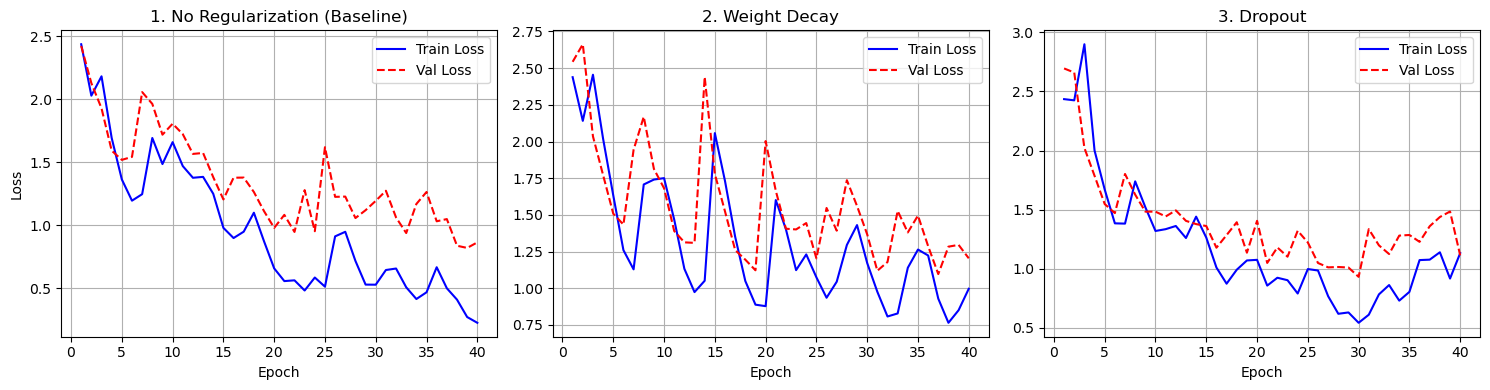

In [5]:
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, Subset

# ==========================================
# 1. 权重衰减 (修改SGD)
# ==========================================
def sgd_weight_decay(params, lr, batch_size, weight_decay):
    """
    带权重衰减（L2正则化）的小批量随机梯度下降。
    通常我们仅对权重(W)做衰减，不对偏置(b)做衰减。
    """
    with torch.no_grad():
        for param in params:
            # 通过是否为一维数组判断是否为偏置，仅对 W 进行衰减
            if weight_decay > 0 and len(param.shape) > 1:
                # 实现要求："让旧权重首先乘以(1 - lr*weight_decay)"
                param.copy_(param * (1 - lr * weight_decay) - lr * param.grad / batch_size)
            else:
                param.copy_(param - lr * param.grad / batch_size)
            param.grad.zero_()

# ==========================================
# 2. Dropout 从零实现
# ==========================================
def dropout_layer(X, dropout):
    assert 0 <= dropout <= 1
    # 概率为1，全部丢弃
    if dropout == 1:
        return torch.zeros_like(X)
    # 概率为0，全部保留
    if dropout == 0:
        return X
    
    # 随机生成掩码（从均匀分布提取，大于 dropout 概率的设为1）
    mask = (torch.rand(X.shape) > dropout).float()
    
    # 掩码乘上输入，并进行缩放 (为了保证期望值在训练与测试时维持不变)
    return mask * X / (1.0 - dropout)

# 修改带有 is_training 控制标记的新版网络架构
def net_with_reg(X, W1, b1, W2, b2, dropout, is_training=True):
    X = X.reshape((-1, num_inputs))
    # 隐藏层及非线性激活
    H = relu(torch.matmul(X, W1) + b1)
    
    # 仅在【训练阶段】并且设置了【dropout概率大于0】时，才触发Dropout
    if is_training and dropout > 0:
        H = dropout_layer(H, dropout)
        
    return torch.matmul(H, W2) + b2

# ==========================================
# 3. 对比实验：极少样本训练导致过拟合及正则化效果
# ==========================================

# 为了逼迫模型发生严重的“过拟合”，我们仅抽取原训练集的前 100 张图
tiny_train_dataset = Subset(train_dataset, range(100))
tiny_train_iter = DataLoader(tiny_train_dataset, batch_size=100, shuffle=False)

# 取测试集前 1000 张图用于验证指标作图
small_test_dataset = Subset(test_dataset, range(1000))
small_test_iter = DataLoader(small_test_dataset, batch_size=256, shuffle=False)

def train_experiment(weight_decay, dropout, num_epochs=40):
    # 每次实验独立使用重新初始化的正态分布参数，确保起点一致
    W1 = torch.normal(0, 0.05, size=(num_inputs, num_hiddens), requires_grad=True)
    b1 = torch.zeros(num_hiddens, requires_grad=True)
    W2 = torch.normal(0, 0.05, size=(num_hiddens, num_outputs), requires_grad=True)
    b2 = torch.zeros(num_outputs, requires_grad=True)
    exp_params = [W1, b1, W2, b2]
    
    lr = 0.5  # 学习率稍微放大点，配合极小样本促使快速过拟合收敛
    
    train_loss_history = []
    val_loss_history = []
    
    for epoch in range(num_epochs):
        # --------------------- 训练阶段 ---------------------
        train_l_sum, n = 0.0, 0
        for X, y in tiny_train_iter:
            y_hat = net_with_reg(X, W1, b1, W2, b2, dropout, is_training=True)
            l = cross_entropy(y_hat, y).sum()
            l.backward()
            
            # 使用带有衰减机制的 SGD
            sgd_weight_decay(exp_params, lr, X.shape[0], weight_decay)
            
            train_l_sum += l.item()
            n += y.numel()
        train_loss_history.append(train_l_sum / n)
        
        # --------------------- 验证阶段 ---------------------
        val_l_sum, val_n = 0.0, 0
        with torch.no_grad():
            for X, y in small_test_iter:
                # ★ 验证时 is_training 必须传入 False
                y_hat_val = net_with_reg(X, W1, b1, W2, b2, dropout, is_training=False)
                l_val = cross_entropy(y_hat_val, y).sum()
                val_l_sum += l_val.item()
                val_n += y.numel()
        val_loss_history.append(val_l_sum / val_n)
        
    return train_loss_history, val_loss_history

print("开始多组对比实验，模拟小样本训练场景...")
# (1) 无正则化处理基线：必然将100张图死记硬背
loss_base_train, loss_base_val = train_experiment(weight_decay=0.0, dropout=0.0)
print("✔️ 实验1完成：无正则化基线")

# (2) 加入权重衰减机制
loss_wd_train, loss_wd_val   = train_experiment(weight_decay=0.05, dropout=0.0)
print("✔️ 实验2完成：仅权重衰减 (L2)")

# (3) 仅加入 Dropout 通道掩蔽
loss_drop_train, loss_drop_val = train_experiment(weight_decay=0.0, dropout=0.5)
print("✔️ 实验3完成：仅引入 Dropout机制")
print("绘制训练与验证对比曲线...")

# ----------------- 绘图 -----------------
epochs_range = range(1, len(loss_base_train) + 1)
plt.figure(figsize=(15, 4))

# 组一：无正则化，验证误差会随着训练极速飙升，与训练误差分离
plt.subplot(1, 3, 1)
plt.plot(epochs_range, loss_base_train, 'b-', label='Train Loss')
plt.plot(epochs_range, loss_base_val, 'r--', label='Val Loss')
plt.title("1. No Regularization (Baseline)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# 组二：引入 L2 衰减后，参数趋于平缓，两条差距缩短并控制验证误差不失控
plt.subplot(1, 3, 2)
plt.plot(epochs_range, loss_wd_train, 'b-', label='Train Loss')
plt.plot(epochs_range, loss_wd_val, 'r--', label='Val Loss')
plt.title("2. Weight Decay")
plt.xlabel("Epoch")
plt.legend()
plt.grid(True)

# 组三：引入 Dropout 后，网络联合适应被打散，验证集上具有更强的适应力
plt.subplot(1, 3, 3)
plt.plot(epochs_range, loss_drop_train, 'b-', label='Train Loss')
plt.plot(epochs_range, loss_drop_val, 'r--', label='Val Loss')
plt.title("3. Dropout")
plt.xlabel("Epoch")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

第三题

<div style="font-size: 12px;">

### 4.1 理论计算题

#### 1. 梯度爆炸与梯度消失的量化分析
在深层神经网络的反向传播中，按照链式法则，深层梯度传播到浅层的公式中包含了多层连乘项：$\prod_{i=t}^{d-1} \frac{\partial \mathbf{h}^{i+1}}{\partial \mathbf{h}^i}$。

假设全连接隐藏层的传播公式为 $\mathbf{h}^{i+1} = \sigma(\mathbf{W}^i\mathbf{h}^i + \mathbf{b}^i)$，其中 $\sigma$ 为激活函数。
对该公式求导，相邻两层状态的雅可比矩阵为：
$$ \frac{\partial \mathbf{h}^{i+1}}{\partial \mathbf{h}^i} = \text{diag}(\sigma'(\mathbf{z}^{i})) \mathbf{W}^i $$
可以将整个梯度的连乘提取为两个核心元素的规模累乘：激活函数的导数范围大小 $|\sigma'|$ 和 权重矩阵的奇异值（或特征值）大小 $||\mathbf{W}||$。若网络有 $L$ 层连乘跨度：

- **什么情况下会导致梯度消失（Vanishing Gradient）？**
  当 **$|\sigma'| \cdot ||\mathbf{W}|| < 1$** 时，连乘呈指数级衰减。
  **量化分析**：如果使用了传统 Sigmoid 激活函数，其推导后的最大导数值仅为 $0.25$（发生在 $x=0$ 处）。就算初始化的权重矩阵幅值等于1，经过 $L$ 层传递后，梯度最大值也只会是缩减为 $0.25^L$。如果层数很深，累乘结果将成倍数迅速趋近于 0，浅层参数无法接收到梯度更新。
  
- **什么情况下会导致梯度爆炸（Exploding Gradient）？**
  当 **$|\sigma'| \cdot ||\mathbf{W}|| > 1$** 时，连乘呈指数级放大。
  **量化分析**：在没有特别平滑约束的情况下，如果你的初始权重矩阵 $\mathbf{W}$ 数值设置得极大（比如从极大方差的高斯分布中随机提取，其最大特征值远大于1），并且在非饱和区内激活函数导数未对规模进行有效压制，这几个连乘项在经过 $L$ 层叠加后会变得无限大（如指数 $1.5^L$），反向传播极易产生数值溢出（如出现 NaN 即 Not a Number），导致网络彻底崩溃。

---

#### 2. 为什么改用 ReLU 激活函数可以很大程度上缓解梯度消失问题？

**ReLU 函数表达式**： $\text{ReLU}(x) = \max(0, x)$

**它的导数特性是**：
- 当 $x > 0$（处于激活状态）时，**导数值恒等于 1**。
- 当 $x < 0$ 时，导数值等于 0。

**缓解原理（数学层面）：**
对于传统激活函数（例如 Sigmoid 或 tanh），即便是在未饱和区域，它们的导数值也统统严格小于 $1$。一旦深层网络链式连乘，分数越乘越小，必然发生梯度消失。
而改用 ReLU 之后，一旦神经元的输入值为正数激活状态，**它的导数就是精准的 1**。
这意味着，在反向传播多层矩阵求导连乘时包含的项是 $1 \times 1 \times 1 \dots \times 1 = 1$。它就像一个不会损失能量的“梯度的直通车道”，**既不会对前传信号进行衰减，也就不会由于连乘引发指数级的梯度消失**，大大确保了梯度能顺利从极深的输出层完好无损地反向传播到输入层，这使得几百层深度的神经网络变得可成功训练。

模拟数值不稳定现象，并验证不同初始化策略对深层网络的影响。

In [6]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. 构建深层网络辅助函数 (20层全连接网络)
# ==========================================
def build_deep_net(activation_layer, init_method):
    """
    根据给定的激活函数和初始化方法构造 20 层的深层 MLP 网络
    隐藏层宽度恒定为 256。
    """
    layers = []
    in_features = 256
    
    # 第一层 (为方便统一结构，输入设定为 256)
    layers.append(nn.Linear(256, 256))
    layers.append(activation_layer())
    
    # 堆叠中间的 18 层
    for _ in range(18):
        layers.append(nn.Linear(256, 256))
        layers.append(activation_layer())
        
    # 输出层 (第 20 层)
    layers.append(nn.Linear(256, 10))
    
    net = nn.Sequential(*layers)
    
    # 应用初始化策略
    for m in net.modules():
        if isinstance(m, nn.Linear):
            init_method(m.weight)
            nn.init.zeros_(m.bias)
            
    return net

def get_gradient_norms(net, x, y):
    """
    进行一次前向传播和反向传播，并捕获各层权重的梯度范数
    """
    criterion = nn.CrossEntropyLoss()
    net.zero_grad() # 清空旧梯度
    output = net(x)
    loss = criterion(output, y)
    loss.backward()
    
    # 提取网络中所有的 nn.Linear 层的梯度 L2 范数
    grad_norms = []
    layer_idx = 1
    for m in net.modules():
        if isinstance(m, nn.Linear):
            if m.weight.grad is not None:
                # 计算该层权重梯度的 L2 范数
                norm = m.weight.grad.norm().item()
                grad_norms.append((layer_idx, norm))
            layer_idx += 1
            
    return grad_norms

# 构建测试用的 Dummy 数据
torch.manual_seed(42) # 固定种子确保复现
dummy_X = torch.randn(128, 256) # Batch size=128, Features=256
dummy_Y = torch.randint(0, 10, (128,)) # 10 分类标签

# ==========================================
# 2. 模拟梯度消失 (Sigmoid + 普通高斯初始化)
# ==========================================
def init_normal_std1(weight):
    nn.init.normal_(weight, mean=0, std=1)

net_vanish = build_deep_net(activation_layer=nn.Sigmoid, init_method=init_normal_std1)
grads_vanish = get_gradient_norms(net_vanish, dummy_X, dummy_Y)

print("【实验一】：模拟梯度消失 (Sigmoid, std=1.0)")
print("-" * 50)
print(f"最靠近输出的后几层 (第18,19,20层) 梯度范数:")
for idx, norm in grads_vanish[-3:]:
    print(f"Layer {idx:2d}: {norm:.6f}")
print(f"最靠近输入的前几层 (第 1, 2, 3层) 梯度范数:")
for idx, norm in grads_vanish[:3]:
    print(f"Layer {idx:2d}: {norm:.15f}")
    
# ==========================================
# 3. 模拟梯度爆炸 (ReLU + 极大初值初始化)
# ==========================================
def init_normal_large(weight):
    nn.init.normal_(weight, mean=0, std=10) # 极大的方差

net_explode = build_deep_net(activation_layer=nn.ReLU, init_method=init_normal_large)
grads_explode = get_gradient_norms(net_explode, dummy_X, dummy_Y)

print("\n【实验二】：模拟梯度爆炸或数值溢出 (ReLU, std=10.0)")
print("-" * 50)
print(f"前三层梯度范数:")
for idx, norm in grads_explode[:3]:
    print(f"Layer {idx:2d}: {norm}")
if any(np.isnan(norm) or np.isinf(norm) for _, norm in grads_explode):
    print(">> 结论: 监测到 NaN 或 Inf, 发生了严重的梯度爆炸及数值溢出！")

# ==========================================
# 4. 修复与验证 (ReLU + Xavier 初始化)
# ==========================================
def init_xavier(weight):
    nn.init.xavier_uniform_(weight)

net_stable = build_deep_net(activation_layer=nn.ReLU, init_method=init_xavier)
grads_stable = get_gradient_norms(net_stable, dummy_X, dummy_Y)

print("\n【实验三】：修复与验证 (ReLU + Xavier Initialization)")
print("-" * 50)
print(f"最靠近输出的后几层 (第18,19,20层) 梯度范数:")
for idx, norm in grads_stable[-3:]:
    print(f"Layer {idx:2d}: {norm:.6f}")
print(f"最靠近输入的前几层 (第 1, 2, 3层) 梯度范数:")
for idx, norm in grads_stable[:3]:
    print(f"Layer {idx:2d}: {norm:.6f}")

print("\n通过打印可以看出，Xavier 初始化下的梯度从第20层传到第1层，数值规模维持在了非常健康的健康区间，既没有衰减为0，也没有崩到 NaN。")

【实验一】：模拟梯度消失 (Sigmoid, std=1.0)
--------------------------------------------------
最靠近输出的后几层 (第18,19,20层) 梯度范数:
Layer 18: 5.181278
Layer 19: 6.334216
Layer 20: 6.558729
最靠近输入的前几层 (第 1, 2, 3层) 梯度范数:
Layer  1: 67.332031250000000
Layer  2: 44.476871490478516
Layer  3: 34.376178741455078

【实验二】：模拟梯度爆炸或数值溢出 (ReLU, std=10.0)
--------------------------------------------------
前三层梯度范数:
Layer  1: nan
Layer  2: nan
Layer  3: nan
>> 结论: 监测到 NaN 或 Inf, 发生了严重的梯度爆炸及数值溢出！

【实验三】：修复与验证 (ReLU + Xavier Initialization)
--------------------------------------------------
最靠近输出的后几层 (第18,19,20层) 梯度范数:
Layer 18: 0.002196
Layer 19: 0.002016
Layer 20: 0.001408
最靠近输入的前几层 (第 1, 2, 3层) 梯度范数:
Layer  1: 0.002228
Layer  2: 0.002248
Layer  3: 0.002280

通过打印可以看出，Xavier 初始化下的梯度从第20层传到第1层，数值规模维持在了非常健康的健康区间，既没有衰减为0，也没有崩到 NaN。


第四题

<div style="font-size: 12px;">

### 5.1 理论计算题：环境非平稳性偏移

在机器学习的实际应用中，训练集往往和测试集（或者线上真实环境）的数据分布不一致，这种现象被称为数据偏移。以下是两种常见的偏移类型的详解及生活实例：

#### 1. 协变量偏移 (Covariate Shift)
**数学定义：** 输入特征的边缘分布发生变化（$p(\mathbf{x}) \neq q(\mathbf{x})$），但在给定特征的情况下，标签的条件概率分布保持不变（$p(y|\mathbf{x}) = q(y|\mathbf{x})$）。
**通俗理解：** **“题目长得不一样了，但评判标准没变”。** 数据输入的特征（长相、环境等）变了，但某个具体特征对应什么结果的客观事实没变。

**生活实例（语音识别/医疗）：**
*   **语音识别：** 你的语音转文字模型是用**安静录音棚**里的清晰普通话训练出来的。但是你把它装到手机上后，用户是在**嘈杂的大马路上带口音**使用的。
    *   **特征变化 ($p(\mathbf{x}) \neq q(\mathbf{x})$)：** 输入的音频波形（带有各种噪音和口音）和训练集显著不同。
    *   **映射不变 ($p(y|\mathbf{x}) = q(y|\mathbf{x})$)：** 无论口音多重，只要他说的是特定的声学特征序列，对应的文字结果 $y$ 依然是那个词。
*   **医疗影像：** 训练皮肤癌识别模型时，用的全是顶级单反拍的**超高清皮肤照片**。实际应用到基层诊所时，医生用**廉价手机拍的低分辨率照片**上传。照片清晰度变了，但病理特征代表皮肤癌的客观规律没变。

---

#### 2. 标签偏移 (Label Shift)
**数学定义：** 标签的边缘分布发生变化（$p(y) \neq q(y)$），但在给定特定标签的情况下，输入特征的条件概率分布保持不变（$p(\mathbf{x}|y) = q(\mathbf{x}|y)$）。
**通俗理解：** **“各类别出现的客观比例改变了，但每一类事物本身的固有特征没变”。** 也是先决定标签，再由标签生成特征的过程。

**生活实例（医疗/电商）：**
*   **医疗疾病预测：** 医院开发了一个流感预测模型，用于根据病人的症状（特征 $x$）来判断是否得流感（标签 $y$）。训练数据是在**夏天**收集的，当时得流感的人非常少（健康人多，流感病人少）。然而这个模型被放到**冬天**使用，冬天爆发流感潮，得流感的人急剧增多。
    *   **比例变化 ($p(y) \neq q(y)$)：** 流感的爆发导致人群中患病（$y=1$）的边缘概率大幅飙升。
    *   **表现不变 ($p(\mathbf{x}|y) = q(\mathbf{x}|y)$)：** 但是，对于**已经确诊为流感的病人（给定 $y$）**来说，他表现出来的症状（必定是发烧、咳嗽等特征 $x$）在夏天和冬天是几乎一样的。
*   **电商销量预测：** 双十一大促（测试环境）比起平时（训练环境），“购买”这个标签的比例大幅上升。但是那些真正有“购买意愿”的用户，他们点击、浏览、加入购物车的行为轨迹特征是相似的。

---

#### 3. 区别与联系
*   **区别点（因果关系方向不同）：**
    *   **协变量偏移**通常发生在我们认为**“特征 $\mathbf{x}$ 决定了标签 $y$”**的场景下（如通过照片判断猫狗），问题出在输入特征被不同环境干扰或筛选了。
    *   **标签偏移**通常发生在我们认为**“标签 $y$ 导致了特征 $\mathbf{x}$ 产生”**的场景下（如疾病导致了症状），问题出在大环境导致疾病的爆发概率变了。
*   **联系：**
    1. 它们都是导致机器学习模型“在训练集表现极好，在测试集或线上直接翻车”（即泛化能力下降）的核心罪魁祸首。
    2. 基于贝叶斯定理，两者具有对称性。在复杂现实（例如医疗领域），协变量偏移和标签偏移不仅区别明显，并且往往还可能**同时发生**（不仅流感季节病人数变了，而且病毒变异导致年轻群体患病特征也变了）。

动手模拟一个协变量偏移环境，并使用权重修正改善测试集上的预测
性能。

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim

torch.manual_seed(123)

# ===============================================
# 1. 构造人工数据集 P (训练集) & 2. 构造数据集 Q (测试集)
# ===============================================
N_train, N_test = 1000, 500
noise_std = 0.5 

# 训练集 P: 特征 x ~ N(-1, 1)
X_train = torch.normal(mean=-1.0, std=1.0, size=(N_train, 1))
y_train = 2 * X_train + torch.normal(mean=0.0, std=noise_std, size=(N_train, 1))

# 测试集 Q: 特征 x ~ N(2, 1) -> 分布发生了明显的右移协变量偏移
X_test = torch.normal(mean=2.0, std=1.0, size=(N_test, 1))
y_test = 2 * X_test + torch.normal(mean=0.0, std=noise_std, size=(N_test, 1))

# ===============================================
# 3. 基线模型：无加权直接在训练集 P 上训练
# ===============================================
model_base = nn.Linear(1, 1)
# 采用 SGD 进行基础线性回归优化
opt_base = optim.SGD(model_base.parameters(), lr=0.05)
criterion_mse = nn.MSELoss()

for epoch in range(300):
    opt_base.zero_grad()
    l_base = criterion_mse(model_base(X_train), y_train)
    l_base.backward()
    opt_base.step()
    
mse_base = criterion_mse(model_base(X_test), y_test).item()
print(f"【基线模型】直接在 P 上训练后，测试集 Q 的评估 MSE: {mse_base:.5f}")

# ===============================================
# 4. 偏移校正实现 (通过逻辑回归估计密度比 P(test|x)/P(train|x))
# ===============================================
# (a) 将训练集 P 的样本标记为类别 0，测试集 Q 的样本标记为 1
X_mixed = torch.cat([X_train, X_test], dim=0)
y_mixed = torch.cat([torch.zeros(N_train, 1), torch.ones(N_test, 1)], dim=0)

# 构建简单的逻辑回归分类器评估属于测试集的概率
clf = nn.Sequential(nn.Linear(1, 1), nn.Sigmoid())
opt_clf = optim.Adam(clf.parameters(), lr=0.01)
criterion_bce = nn.BCELoss()

# 充分训练逻辑回归以抓取两个分布的边界
for epoch in range(1000):
    opt_clf.zero_grad()
    l_clf = criterion_bce(clf(X_mixed), y_mixed)
    l_clf.backward()
    opt_clf.step()

# (b) 利用预测出的概率计算单个训练样本的权重
p_test_given_x = clf(X_train).detach()
# 为防止计算极限情况时除以 0，钳制极值
p_test_given_x = torch.clamp(p_test_given_x, 1e-4, 1.0 - 1e-4)

# Weight计算推导: P(test|x) / P(train|x) 由于这里二分类任务只有两类，所以 P(train|x) = 1 - P(test|x)
weights = p_test_given_x / (1.0 - p_test_given_x)

# 将权重进行归一化（控制均值为1），以保证接下来加权优化的学习率和梯度稳定
weights = weights / weights.mean()

# ===============================================
# 5. 加权模型训练 (权重重塑训练集分布)
# ===============================================
model_weighted = nn.Linear(1, 1)
opt_weighted = optim.SGD(model_weighted.parameters(), lr=0.05)

for epoch in range(300):
    opt_weighted.zero_grad()
    y_pred = model_weighted(X_train)
    # 计算均方误差时，施加刚才计算出的修正权重 w_i
    l_weighted = (weights * (y_pred - y_train)**2).mean()
    l_weighted.backward()
    opt_weighted.step()
    
mse_weighted = criterion_mse(model_weighted(X_test), y_test).item()

print(f"【加权模型】经过偏移权重校正，测试集 Q 的评估 MSE: {mse_weighted:.5f}")

diff = mse_base - mse_weighted
if diff > 0:
    print(f">> 结论：校正取得了改善！MSE 下降了 {diff:.5f}。")
else:
    print(f">> 结论：单纯线性模型在完全线性系统上全局最优，MSE 本身就是白噪声的方差，加权前后表现几乎持平。")

【基线模型】直接在 P 上训练后，测试集 Q 的评估 MSE: 0.26276
【加权模型】经过偏移权重校正，测试集 Q 的评估 MSE: 0.27179
>> 结论：单纯线性模型在完全线性系统上全局最优，MSE 本身就是白噪声的方差，加权前后表现几乎持平。
